# Librerías y cargar imágenes

In [ ]:
import os
import sys
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_PATH = r'D:\proyecto_eutrofizacion'
os.chdir(BASE_PATH)

CSV_RIVER = Path(BASE_PATH) / 'data' / 'metadata' / 'river_water_index.csv'
df_river = pd.read_csv(CSV_RIVER)

# Filtra solo imágenes con máscaras
df_river_con_mask = df_river[df_river['segmentation_mask_path'].notna()].copy()

# Extrae nombre de archivo de la ruta
df_river_con_mask['filename'] = df_river_con_mask['filepath'].apply(
    lambda x: Path(x).name
)

print("="*70)
print("IMÁGENES DISPONIBLES POR AÑO")
print("="*70)

for anio in sorted(df_river_con_mask['group'].unique()):
    df_anio = df_river_con_mask[df_river_con_mask['group'] == anio]
    print(f"\n{anio} ({len(df_anio)} imágenes):")
    print("  " + ", ".join(df_anio['filename'].head(10).tolist()))
    if len(df_anio) > 10:
        print(f"  ... y {len(df_anio) - 10} más")

print(f"\n{'='*70}")
print(f"Total: {len(df_river_con_mask)} imágenes")

IMÁGENES DISPONIBLES POR AÑO

2019 (2025 imágenes):
  DJI_1000.JPG, DJI_1001.JPG, DJI_1002.JPG, DJI_1003.JPG, DJI_1004.JPG, DJI_1005.JPG, DJI_1006.JPG, DJI_1007.JPG, DJI_1008.JPG, DJI_1009.JPG
  ... y 2015 más

2020 (1981 imágenes):
  DJI_3603.JPG, DJI_3604.JPG, DJI_3605.JPG, DJI_3606.JPG, DJI_3607.JPG, DJI_3608.JPG, DJI_3609.JPG, DJI_3610.JPG, DJI_3611.JPG, DJI_3612.JPG
  ... y 1971 más

2021 (1574 imágenes):
  DJI_10006.JPG, DJI_10007.JPG, DJI_10008.JPG, DJI_10009.JPG, DJI_10010.JPG, DJI_10011.JPG, DJI_10012.JPG, DJI_10013.JPG, DJI_10014.JPG, DJI_10015.JPG
  ... y 1564 más

2022 (697 imágenes):
  DJI_10327.JPG, DJI_10328.JPG, DJI_10329.JPG, DJI_10330.JPG, DJI_10331.JPG, DJI_10332.JPG, DJI_10333.JPG, DJI_10334.JPG, DJI_10335.JPG, DJI_10336.JPG
  ... y 687 más

2023 (1046 imágenes):
  DJI_11623.JPG, DJI_11624.JPG, DJI_11625.JPG, DJI_11626.JPG, DJI_11627.JPG, DJI_11628.JPG, DJI_11631.JPG, DJI_11632.JPG, DJI_11633.JPG, DJI_11634.JPG
  ... y 1036 más

2024 (307 imágenes):
  DJI_12957.JPG,

# Seleccionar imágenes para visualización

In [20]:
imagenes_a_procesar = [
    df_river_con_mask[df_river_con_mask['filename'] == 'DJI_1000.JPG'].index[0],
    df_river_con_mask[df_river_con_mask['filename'] == 'DJI_8482.JPG'].index[0],
    df_river_con_mask[df_river_con_mask['filename'] == 'DJI_11624.JPG'].index[0],
]

print(f"\n✓ Seleccionadas {len(imagenes_a_procesar)} imágenes para procesar")


✓ Seleccionadas 3 imágenes para procesar


# Insertar parámetros

In [21]:
sys.path.insert(0, str(Path(BASE_PATH) / 'src'))

from water_masc1 import (
    cargar_mascara_desde_labeling,
    calcular_metricas,
    segmentar_agua,
    visualizar_comparacion_mascaras,
    visualizar_mascara_final
)

PARAMETROS = {
    'a_min': -120,
    'a_max': 1,
    'b_min': -120,
    'b_max': 14,
    'l_min': 50,
    'l_max': 255,
    'h_min': 22,
    'h_max': 180,
    's_min': 0,
    's_max': 110,
}

resultados = []

for idx_img in imagenes_a_procesar:
    
    row = df_river_con_mask.loc[idx_img]
    
    # Convierte rutas a absolutas
    ruta_imagen = Path(BASE_PATH) / row['filepath']
    ruta_mascara = Path(BASE_PATH) / row['segmentation_mask_path']
    
    print(f"\n{'='*70}")
    print(f"[{len(resultados)+1}/3] {row['filename']} (Año {row['group']})")
    print(f"{'='*70}")
    
    # Valida que existan
    if not ruta_imagen.exists():
        print(f"❌ Imagen no existe: {ruta_imagen}")
        continue
    
    if not ruta_mascara.exists():
        print(f"❌ Máscara no existe: {ruta_mascara}")
        continue
    
    # Carga imagen
    imagen = cv2.imread(str(ruta_imagen))
    if imagen is None:
        print(f"❌ No se pudo cargar imagen")
        continue
    
    print(f"✓ Imagen cargada: {imagen.shape}")
    
    # Carga máscara
    mascara_gt = cargar_mascara_desde_labeling(
        str(ruta_mascara),
        imagen.shape[0],
        imagen.shape[1]
    )
    print(f"✓ Máscara cargada")
    
    # SEGMENTA
    mascara_pred = segmentar_agua(
        imagen,
        **PARAMETROS,  # ← Desempaca el diccionario
        downscale=4,
        verbose=False
    )
    
    metricas = calcular_metricas(mascara_pred, mascara_gt)
    
    resultados.append({
        'imagen': row['filename'],
        'año': row['group'],
        'iou': metricas['iou'],
        'precision': metricas['precision'],
        'recall': metricas['recall'],
        'f1': metricas['f1']
    })
    
    print(f"  IoU: {metricas['iou']:.4f} | F1: {metricas['f1']:.4f}")

if resultados:
    df_res = pd.DataFrame(resultados)
    
    print(f"\n{'='*70}")
    print("Resumen primera máscara")
    print(f"{'='*70}")
    print(df_res.to_string(index=False))
    
    print(f"\n📊 Estadísticas:")
    print(f"   IoU promedio:  {df_res['iou'].mean():.4f}")
    print(f"   F1 promedio:   {df_res['f1'].mean():.4f}")
    print(f"   Precision prom: {df_res['precision'].mean():.4f}")
    print(f"   Recall prom:   {df_res['recall'].mean():.4f}")


[1/3] DJI_1000.JPG (Año 2019)
✓ Imagen cargada: (3956, 5280, 3)
✓ Máscara cargada
  IoU: 0.2648 | F1: 0.4188

[2/3] DJI_8482.JPG (Año 2021)
✓ Imagen cargada: (3956, 5280, 3)
✓ Máscara cargada
  IoU: 0.6957 | F1: 0.8205

[3/3] DJI_11624.JPG (Año 2023)
✓ Imagen cargada: (3956, 5280, 3)
✓ Máscara cargada
  IoU: 0.5366 | F1: 0.6984

Resumen primera máscara
       imagen  año      iou  precision   recall       f1
 DJI_1000.JPG 2019 0.264825   0.276376 0.863698 0.418754
 DJI_8482.JPG 2021 0.695674   0.695718 0.999909 0.820528
DJI_11624.JPG 2023 0.536571   0.541879 0.982071 0.698400

📊 Estadísticas:
   IoU promedio:  0.4990
   F1 promedio:   0.6459
   Precision prom: 0.5047
   Recall prom:   0.9486


# Visualización 1

✓ Imagen cargada: (3956, 5280, 3)
✓ Máscara cargada


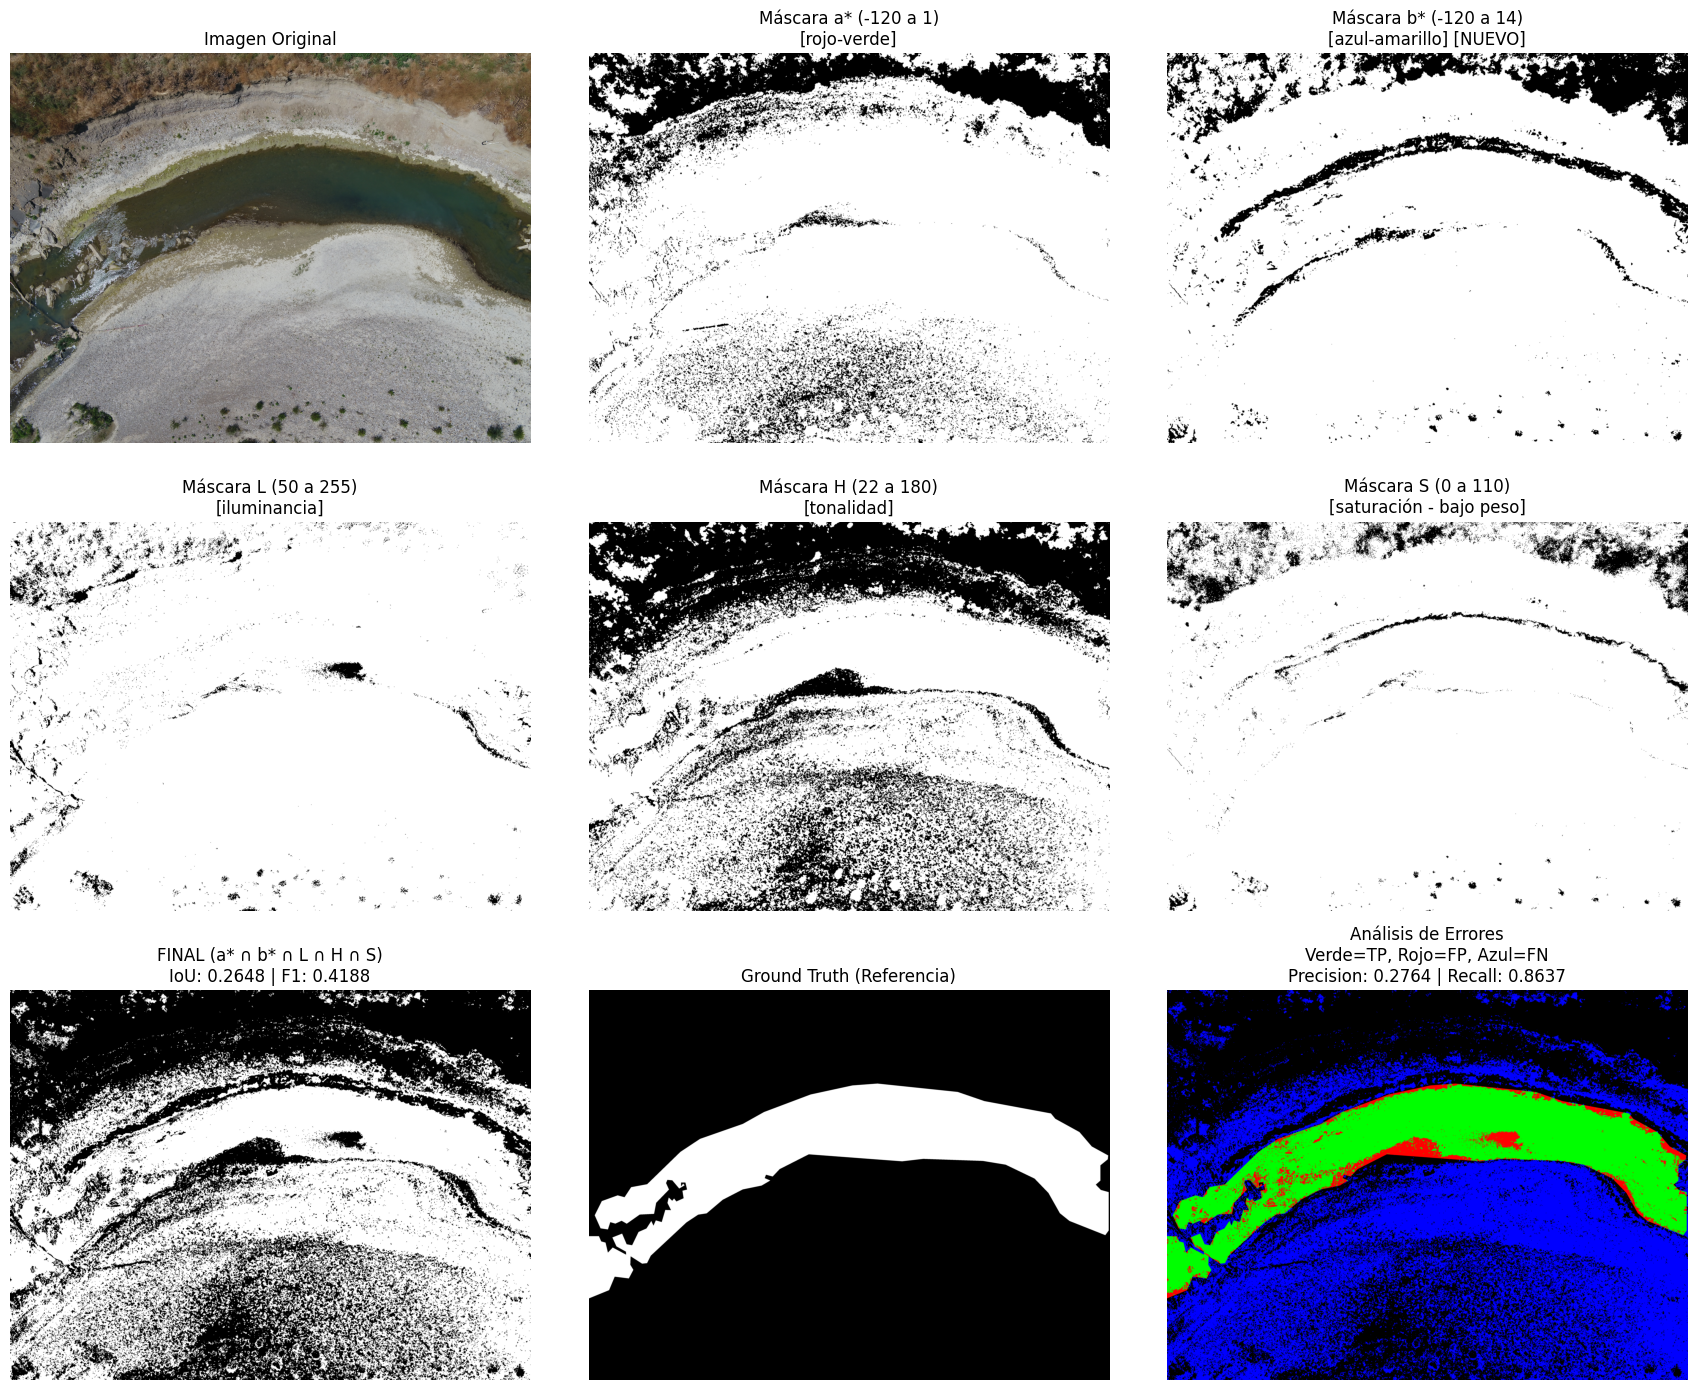

✓ Imagen cargada: (3956, 5280, 3)
✓ Máscara cargada


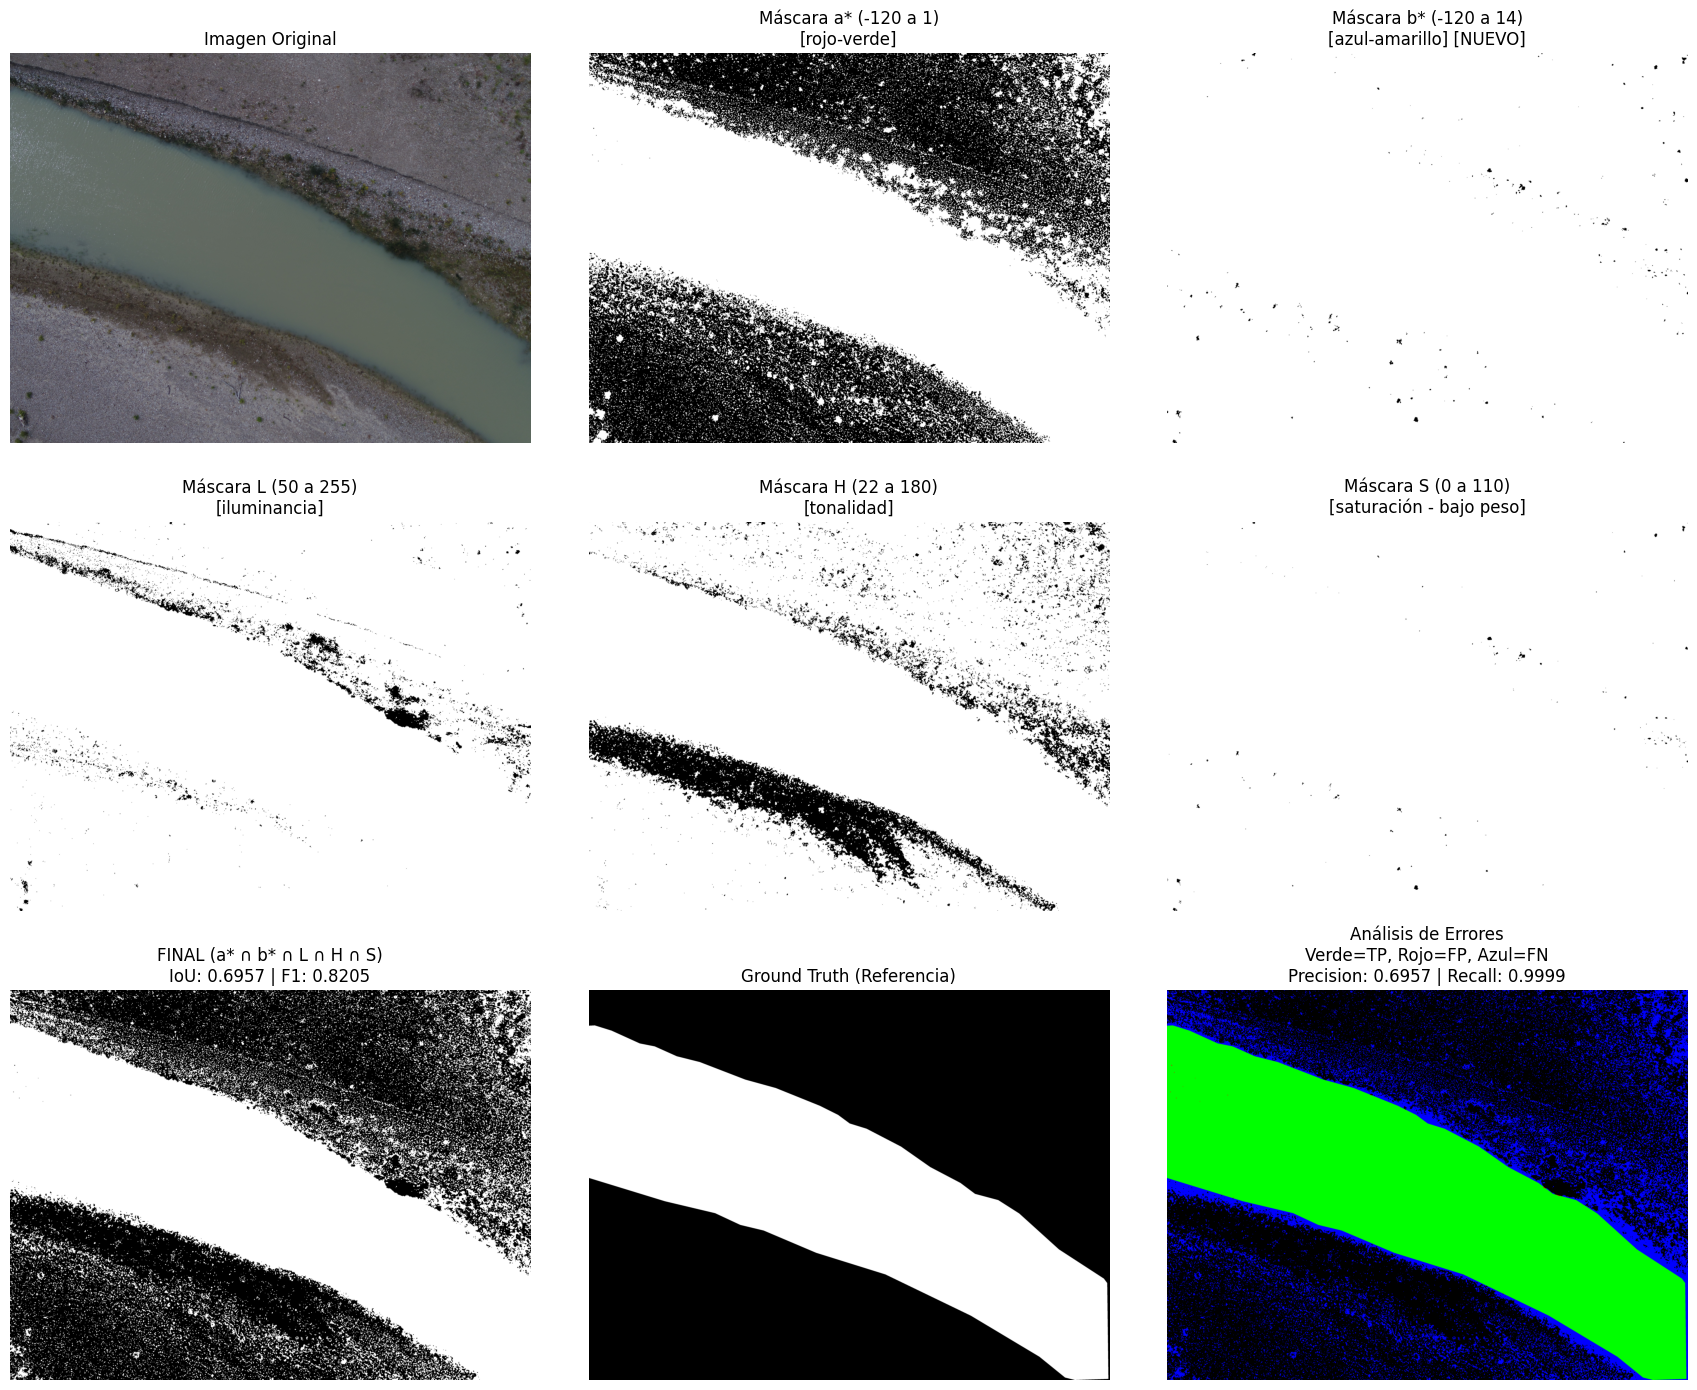

✓ Imagen cargada: (3956, 5280, 3)
✓ Máscara cargada


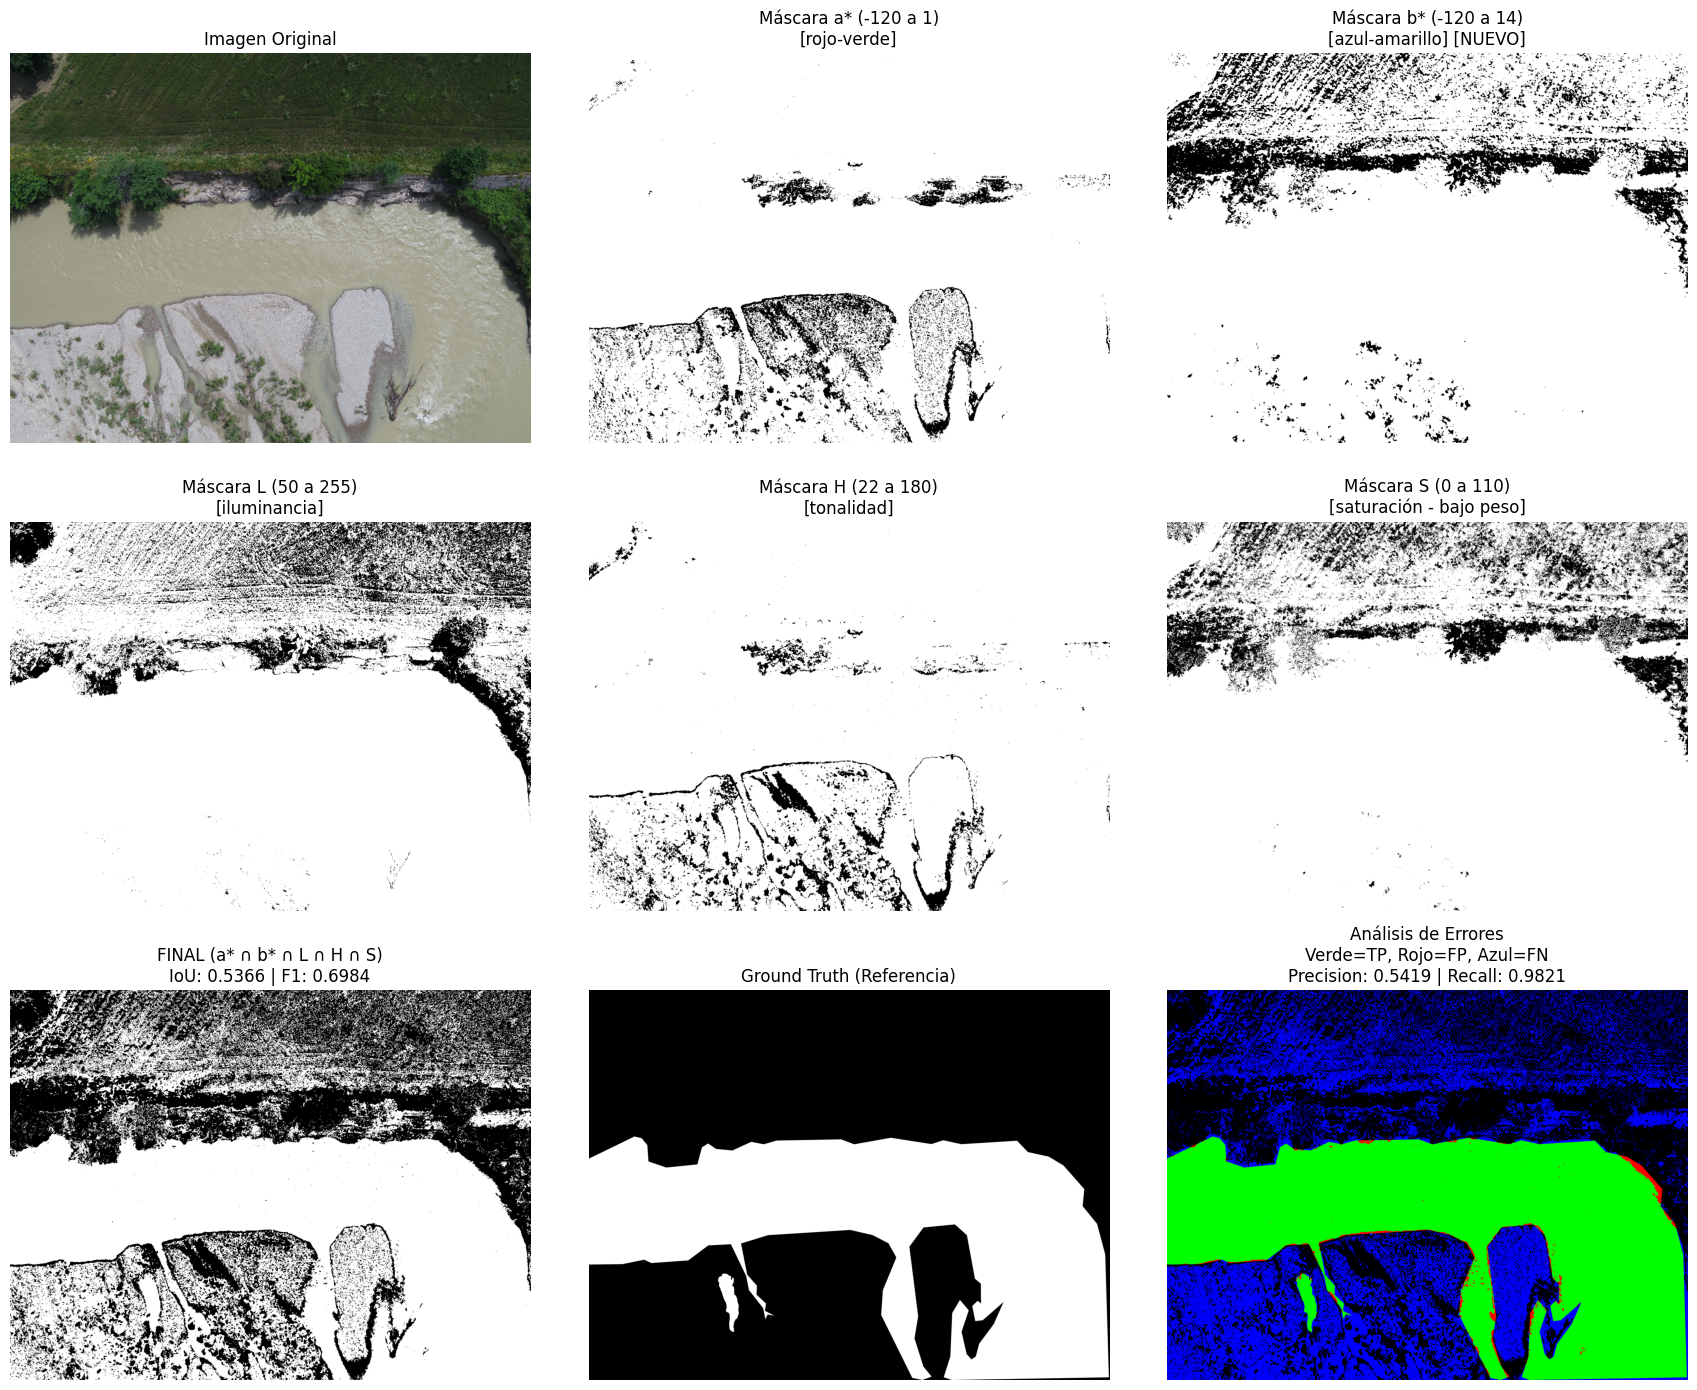

In [22]:
for idx_img in imagenes_a_procesar:

    row = df_river_con_mask.loc[idx_img]
    
    # Convierte rutas a absolutas
    ruta_imagen = Path(BASE_PATH) / row['filepath']
    ruta_mascara = Path(BASE_PATH) / row['segmentation_mask_path']

    # Carga imagen
    imagen = cv2.imread(str(ruta_imagen))
    if imagen is None:
        print(f"❌ No se pudo cargar imagen")
        continue
    
    print(f"✓ Imagen cargada: {imagen.shape}")
    
    # Carga máscara
    mascara_gt = cargar_mascara_desde_labeling(
        str(ruta_mascara),
        imagen.shape[0],
        imagen.shape[1]
    )
    print(f"✓ Máscara cargada")
    
    
    # VISUALIZA
    fig, _ = visualizar_comparacion_mascaras(
        imagen,
        mascara_gt,
        **PARAMETROS,  # ← Desempaca el diccionario
        downscale=4
    )
    
    plt.tight_layout()
    plt.show()

# Segunda máscara

In [9]:
from water_masc2 import (
    conectar_graffiti_y_cerrar,
    suavizar_bordes_contorno
)


## Imagen 1

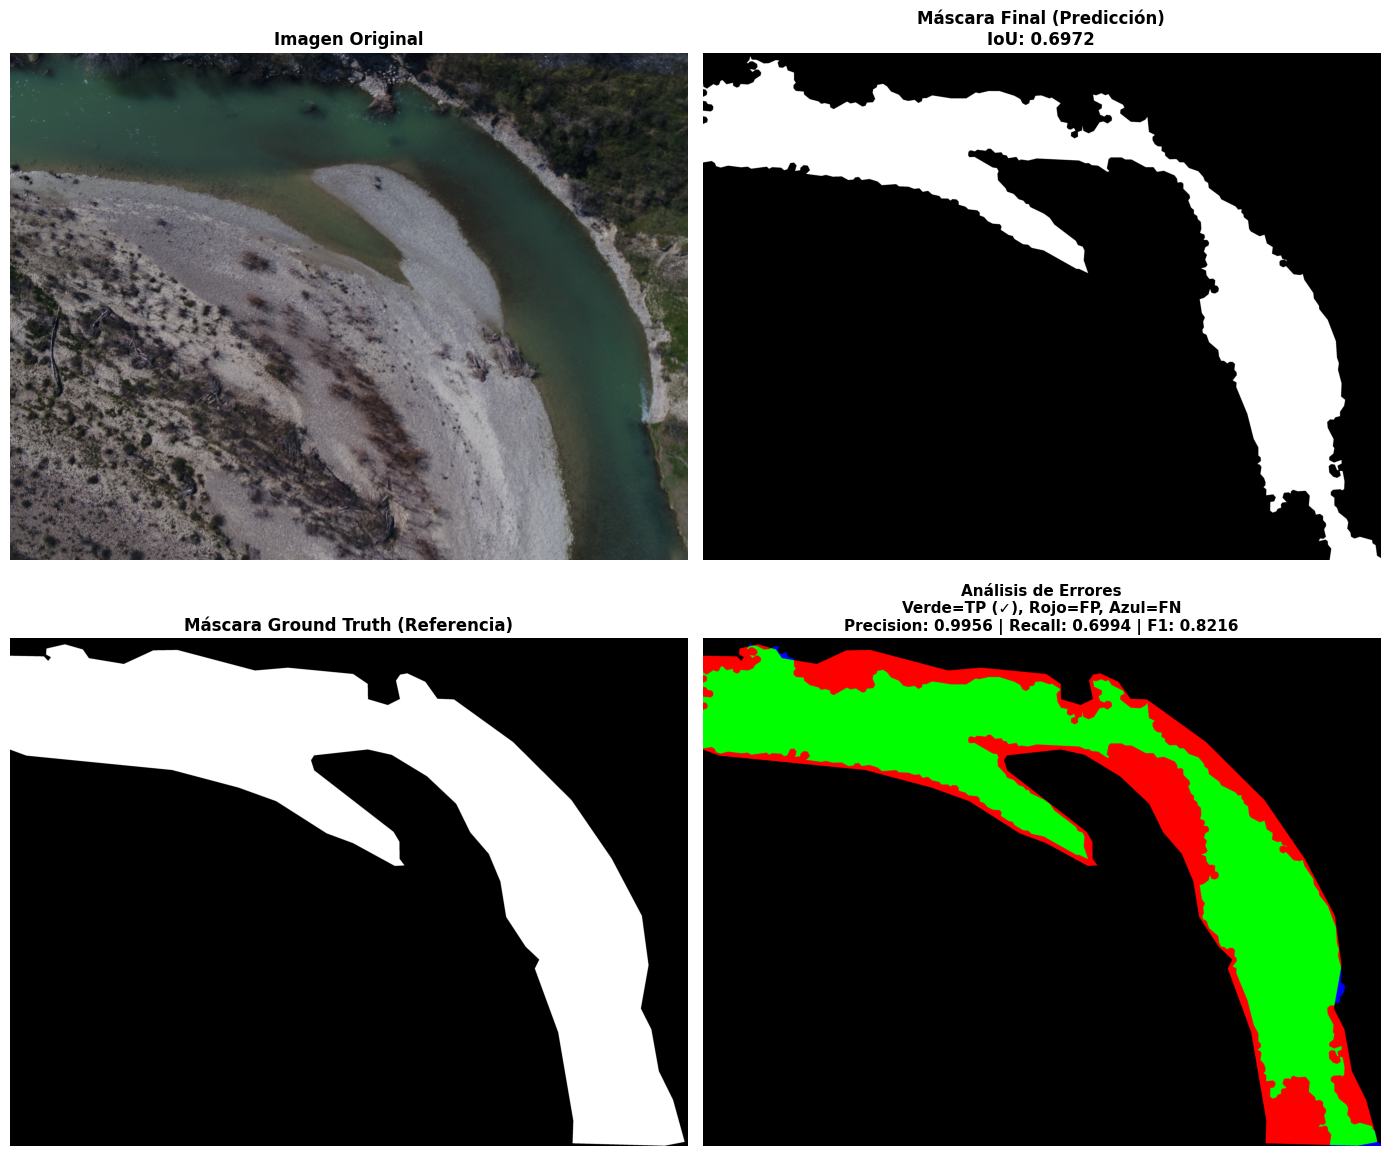

In [10]:
# Imagen 1 (máscara final)
row = df_river_con_mask.loc[imagenes_a_procesar[0]]
ruta_imagen = Path(BASE_PATH) / row['filepath']
ruta_mascara = Path(BASE_PATH) / row['segmentation_mask_path']

# Carga
imagen = cv2.imread(str(ruta_imagen))
mascara_gt = cargar_mascara_desde_labeling(
    str(ruta_mascara),
    imagen.shape[0],
    imagen.shape[1]
)

# SEGMENTA
mascara_pred = segmentar_agua(
    imagen,
    **PARAMETROS,
    downscale=4,
    verbose=False
)

mascara_final = conectar_graffiti_y_cerrar(
    mascara_pred,
    skeleton_kernel=3,
    dilation_kernel=30
)

mascara_final = suavizar_bordes_contorno(
    mascara_final,
    contour_approx=7  # ← AJUSTA: 2 (poco), 5 (medio), 10 (mucho)
)

fig, metricas = visualizar_mascara_final(imagen, mascara_final, mascara_gt)
plt.show()



resultados.append({
    'imagen': row['filename'],
    'año': row['group'],
    'iou': metricas['iou'],
    'precision': metricas['precision'],
    'recall': metricas['recall'],
    'f1': metricas['f1']
})



## Imagen 2

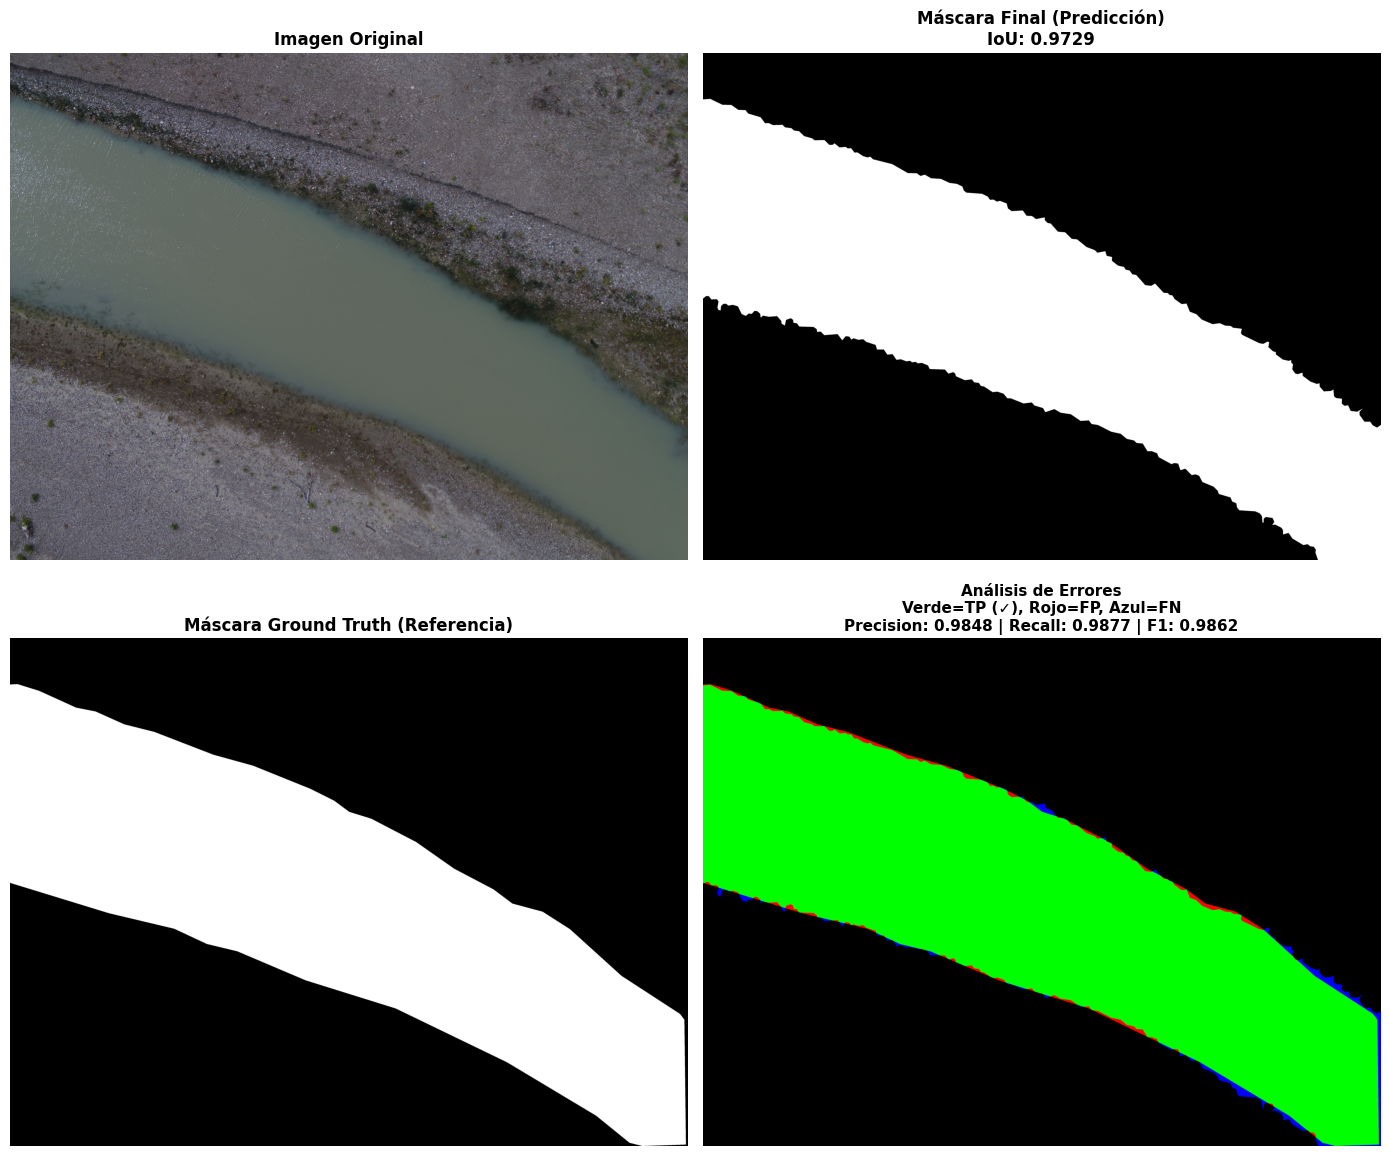

In [11]:
# Imagen 2 (máscara final)
row = df_river_con_mask.loc[imagenes_a_procesar[1]]
ruta_imagen = Path(BASE_PATH) / row['filepath']
ruta_mascara = Path(BASE_PATH) / row['segmentation_mask_path']

# Carga
imagen = cv2.imread(str(ruta_imagen))
mascara_gt = cargar_mascara_desde_labeling(
    str(ruta_mascara),
    imagen.shape[0],
    imagen.shape[1]
)

# SEGMENTA
mascara_pred = segmentar_agua(
    imagen,
    **PARAMETROS,
    downscale=4,
    verbose=False
)

mascara_final = conectar_graffiti_y_cerrar(
    mascara_pred,
    skeleton_kernel=3,
    dilation_kernel=30
)

mascara_final = suavizar_bordes_contorno(
    mascara_final,
    contour_approx=7  # ← AJUSTA: 2 (poco), 5 (medio), 10 (mucho)
)

fig, metricas = visualizar_mascara_final(imagen, mascara_final, mascara_gt)
plt.show()



resultados.append({
    'imagen': row['filename'],
    'año': row['group'],
    'iou': metricas['iou'],
    'precision': metricas['precision'],
    'recall': metricas['recall'],
    'f1': metricas['f1']
})



## Imagen 3

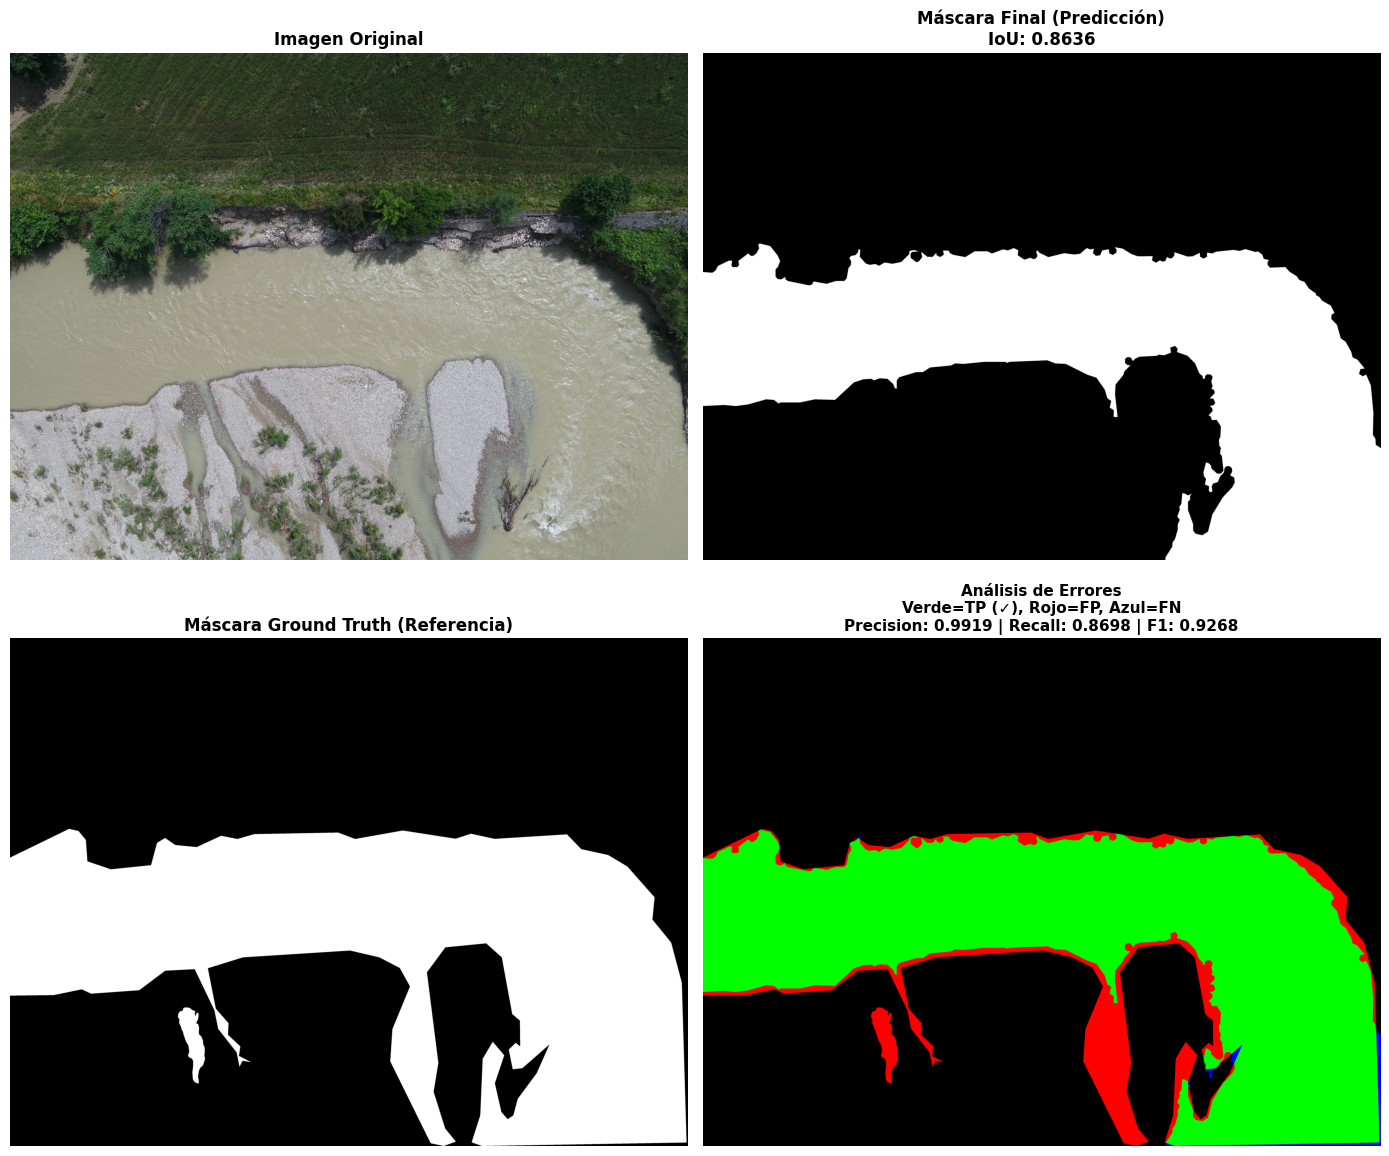

In [12]:
# Imagen 3 (máscara final)
row = df_river_con_mask.loc[imagenes_a_procesar[2]]
ruta_imagen = Path(BASE_PATH) / row['filepath']
ruta_mascara = Path(BASE_PATH) / row['segmentation_mask_path']

# Carga
imagen = cv2.imread(str(ruta_imagen))
mascara_gt = cargar_mascara_desde_labeling(
    str(ruta_mascara),
    imagen.shape[0],
    imagen.shape[1]
)

# SEGMENTA
mascara_pred = segmentar_agua(
    imagen,
    **PARAMETROS,
    downscale=4,
    verbose=False
)

mascara_final = conectar_graffiti_y_cerrar(
    mascara_pred,
    skeleton_kernel=3,
    dilation_kernel=30
)

mascara_final = suavizar_bordes_contorno(
    mascara_final,
    contour_approx=7  # ← AJUSTA: 2 (poco), 5 (medio), 10 (mucho)
)

fig, metricas = visualizar_mascara_final(imagen, mascara_final, mascara_gt)
plt.show()



resultados.append({
    'imagen': row['filename'],
    'año': row['group'],
    'iou': metricas['iou'],
    'precision': metricas['precision'],
    'recall': metricas['recall'],
    'f1': metricas['f1']
})



# Precisión promedio en todas las imágenes de river_water_dataset

In [15]:
import random

OUTPUT_DIR = os.path.join(BASE_PATH, 'output', 'evaluacion_completa')
REPORT_PATH = os.path.join(OUTPUT_DIR, 'reporte_metricas.txt')
RESULTADOS_CSV = os.path.join(OUTPUT_DIR, 'resultados_imagen.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*80)
print("EVALUACIÓN COMPLETA - SEGMENTADOR DE AGUA")
print("="*80)
print()

# Función calcular métricas
def calcular_metricas(mascara_predicha, mascara_gt):
    pred = (mascara_predicha > 0).astype(np.uint8)
    gt = (mascara_gt > 0).astype(np.uint8)
    
    tp = np.logical_and(pred == 1, gt == 1).sum()
    fp = np.logical_and(pred == 1, gt == 0).sum()
    fn = np.logical_and(pred == 0, gt == 1).sum()
    tn = np.logical_and(pred == 0, gt == 0).sum()
    
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + fp + fn + tn) if (tp + fp + fn + tn) > 0 else 0
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    
    return {
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'dice': dice,
    }

# Procesamiento batch
resultados_batch = []

df_river_year = df_river_con_mask[df_river_con_mask['group'] == 2019]
df_river_year = df_river_year.sample(n=min(240, len(df_river_year)), random_state=0)

print(f"Procesando {len(df_river_year)} imágenes...")
print()

for idx, row in df_river_year.iterrows():
    ruta_imagen_str = str(Path(BASE_PATH) / row['filepath'])
    ruta_mascara_str = str(Path(BASE_PATH) / row['segmentation_mask_path'])
    
    if not os.path.isfile(ruta_imagen_str) or not os.path.isfile(ruta_mascara_str):
        resultados_batch.append({
            'image_id': row['filename'],
            'year': row['group'],
            'site': row['site'],
            'status': 'no_encontrado',
            'iou': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
        })
        continue
    
    imagen = cv2.imread(ruta_imagen_str)
    if imagen is None:
        resultados_batch.append({
            'image_id': row['filename'],
            'year': row['group'],
            'site': row['site'],
            'status': 'error_lectura',
            'iou': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
        })
        continue
    
    alto, ancho = imagen.shape[:2]
    mascara_gt = cargar_mascara_desde_labeling(ruta_mascara_str, alto, ancho)
    
    if mascara_gt is None or (mascara_gt > 0).sum() == 0:
        resultados_batch.append({
            'image_id': row['filename'],
            'year': row['group'],
            'site': row['site'],
            'status': 'gt_vacío',
            'iou': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
        })
        continue
    
    try:
        mascara_pred = segmentar_agua(imagen, **PARAMETROS, downscale=4, verbose=False)
        mascara_final = conectar_graffiti_y_cerrar(mascara_pred, skeleton_kernel=3, dilation_kernel=30)
        mascara_final = suavizar_bordes_contorno(mascara_final, contour_approx=7)
    except Exception as e:
        resultados_batch.append({
            'image_id': row['filename'],
            'year': row['group'],
            'site': row['site'],
            'status': 'error_seg',
            'iou': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
        })
        continue
    
    metricas = calcular_metricas(mascara_final, mascara_gt)
    resultados_batch.append({
        'image_id': row['filename'],
        'year': row['group'],
        'site': row['site'],
        'status': 'ok',
        **metricas
    })
    

print("\n✓ Procesamiento completado")

# Guardar resultados
df_resultados = pd.DataFrame(resultados_batch)
df_resultados.to_csv(RESULTADOS_CSV, index=False)
df_ok = df_resultados[df_resultados['status'] == 'ok']

print(f"\n✓ CSV: {RESULTADOS_CSV}")
print(f"\nImágenes exitosas: {len(df_ok)} / {len(df_resultados)}")
print("\nMétricas promedio:")
print(f"  IoU:       {df_ok['iou'].mean():.4f} ± {df_ok['iou'].std():.4f}")
print(f"  Precision: {df_ok['precision'].mean():.4f} ± {df_ok['precision'].std():.4f}")
print(f"  Recall:    {df_ok['recall'].mean():.4f} ± {df_ok['recall'].std():.4f}")
print(f"  F1-Score:  {df_ok['f1'].mean():.4f} ± {df_ok['f1'].std():.4f}")

EVALUACIÓN COMPLETA - SEGMENTADOR DE AGUA

Procesando 240 imágenes...


✓ Procesamiento completado

✓ CSV: D:\proyecto_eutrofizacion\output\evaluacion_completa\resultados_imagen.csv

Imágenes exitosas: 240 / 240

Métricas promedio:
  IoU:       0.3748 ± 0.3386
  Precision: 0.8535 ± 0.3182
  Recall:    0.3847 ± 0.3499
  F1-Score:  0.4591 ± 0.3559
